# IBM Customer Churn Analysis and Prediction

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

## Data Preparation

In [92]:
# Load and Check Dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [93]:
# Check Dataset Structure
print(df.info())
print(df.describe())
print("\nMissing Values:\n", df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [94]:
# Fix the TotalCharges column
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop rows with missing values
df = df.dropna(subset=["TotalCharges"])


## Exploratory Data Analysis

Churn Value Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Proportion:
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


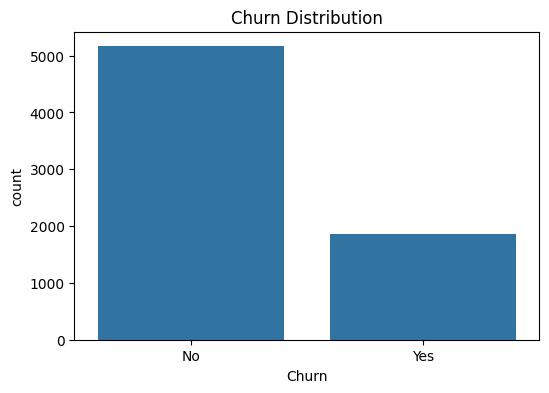

In [95]:
# Check Churn Distribution
print("Churn Value Counts:")
print(df["Churn"].value_counts())

print("\nChurn Proportion:")
print(df["Churn"].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [96]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


/var/folders/zb/cc1txqfj67jbtr91_h72hwt00000gn/T/ipykernel_9525/3305746843.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


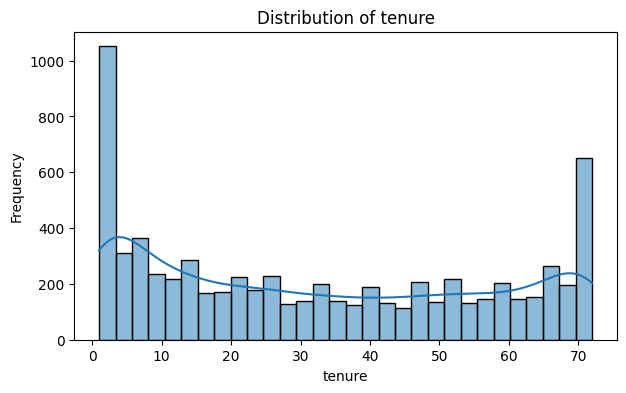

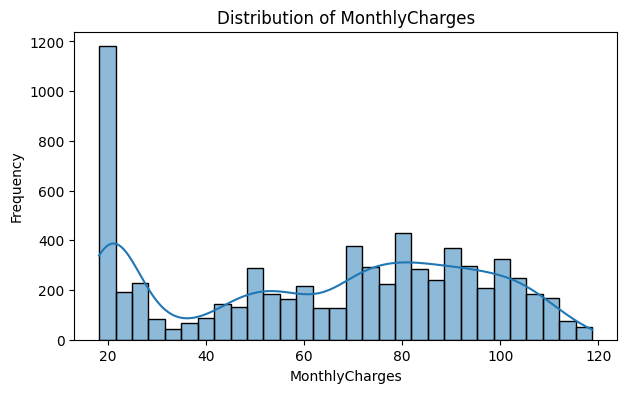

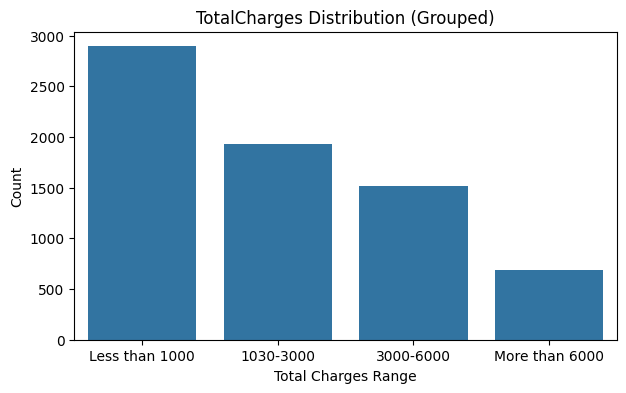

In [97]:
# Explore important numerical features against churn
# Separate numerical columns
important_num_cols = ["tenure", "MonthlyCharges"]

# Plot Histograms for Tenure and MonthlyCharges
for col in important_num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Create Ranges
df["TotalCharges_Group"] = pd.cut(
    df["TotalCharges"],
    bins=[0, 1000, 3000, 6000, np.inf],
    labels=["Less than 1000", "1030-3000", "3000-6000", "More than 6000"]
)

# Plot the Grouped TotalCharges
plt.figure(figsize=(7, 4))
sns.countplot(x="TotalCharges_Group", data=df)
plt.title("TotalCharges Distribution (Grouped)")
plt.xlabel("Total Charges Range")
plt.ylabel("Count")
plt.show()

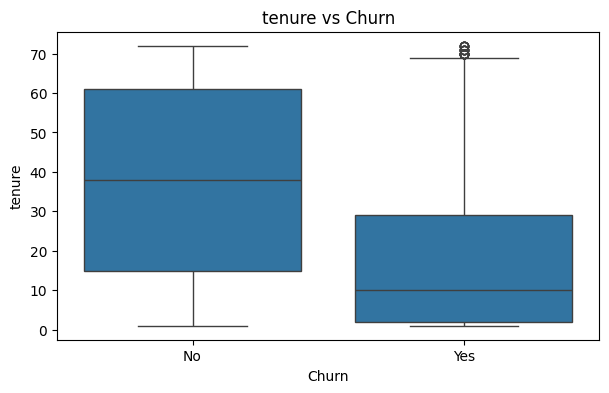

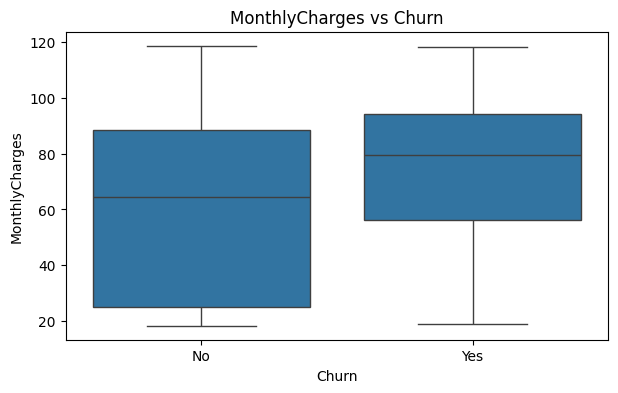

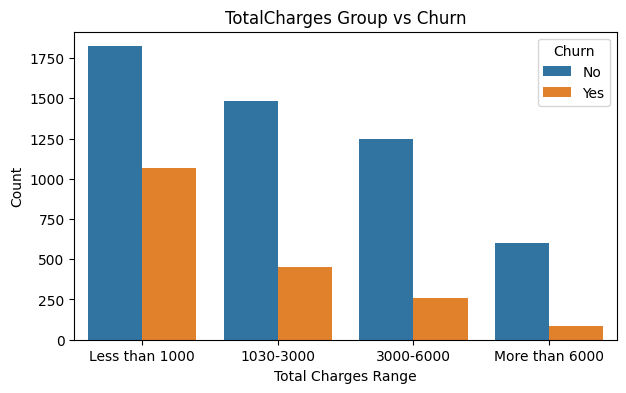

In [98]:
# Compare Numerical Features against Churn
important_num_cols = ["tenure", "MonthlyCharges"]

# Plot for Tenure and MonthlyCharges using boxplot
for col in important_num_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

# Plot for TotalCharges using countplot
plt.figure(figsize=(7, 4))
sns.countplot(x="TotalCharges_Group", hue="Churn", data=df)
plt.title("TotalCharges Group vs Churn")
plt.xlabel("Total Charges Range")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

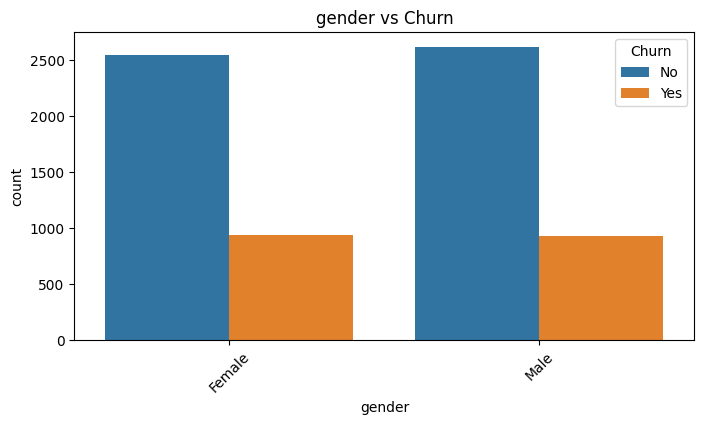

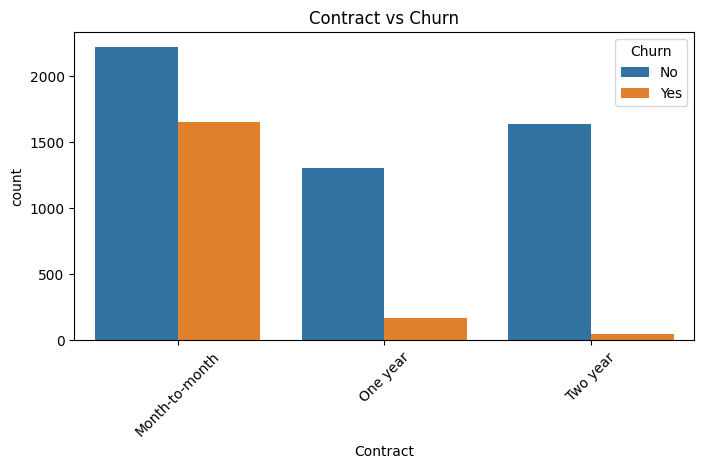

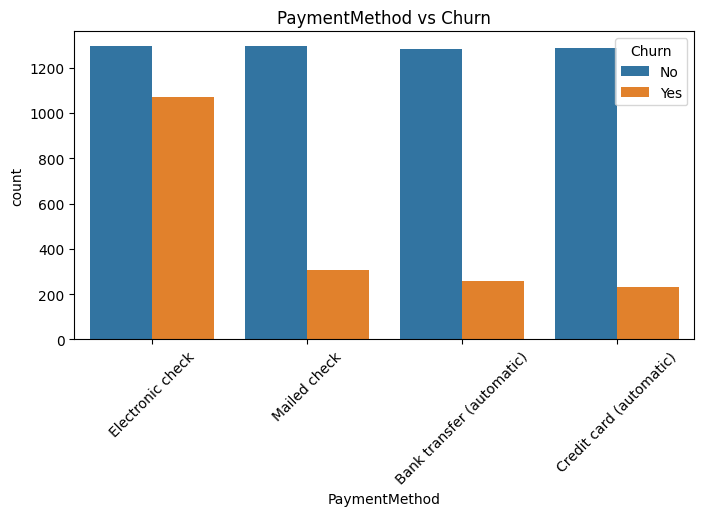

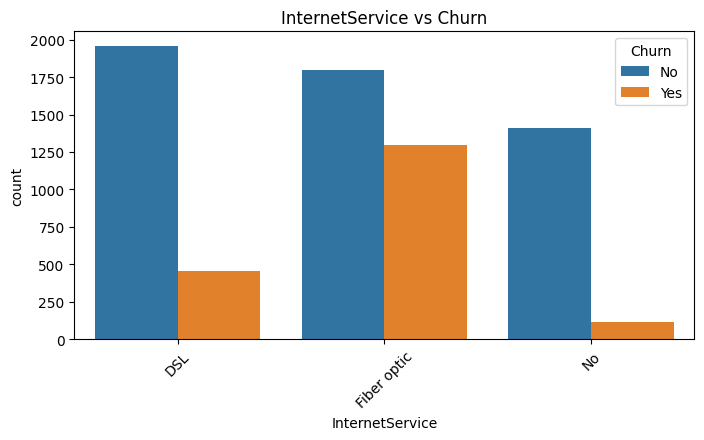

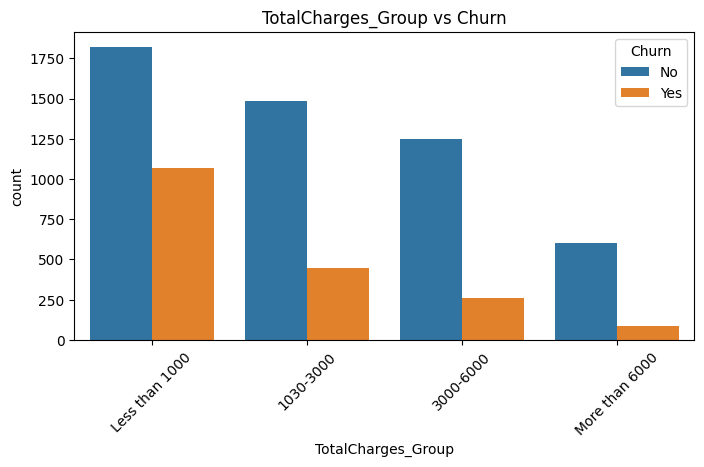

In [99]:
# Explore Important Categorical Features against Churn
important_cat_cols = [
    "gender",
    "Contract",
    "PaymentMethod",
    "InternetService",
    "TotalCharges_Group"
]

for col in important_cat_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.countplot(x=col, hue="Churn", data=df)
        plt.title(f"{col} vs Churn")
        plt.xticks(rotation=45)
        plt.show()

TotalCharges Group vs Churn (Counts):


Churn,No,Yes
TotalCharges_Group,,
Less than 1000,1823,1070
1030-3000,1486,449
3000-6000,1250,262
More than 6000,604,88


TotalCharges Group vs Churn (Percentage):


Churn,No,Yes
TotalCharges_Group,,
Less than 1000,63.01,36.99
1030-3000,76.80,23.20
3000-6000,82.67,17.33
More than 6000,87.28,12.72


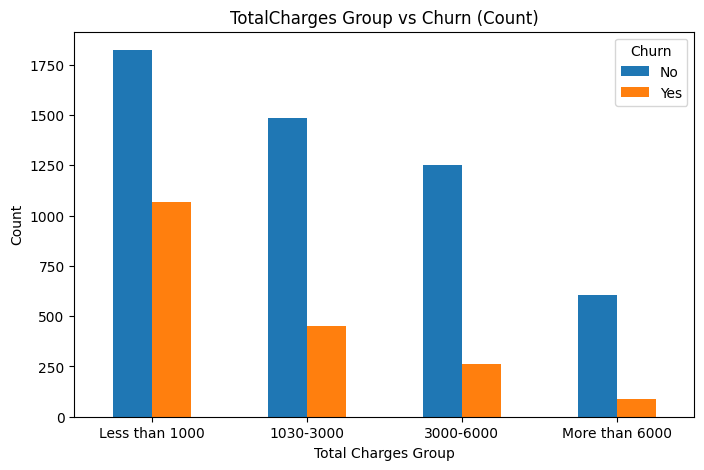

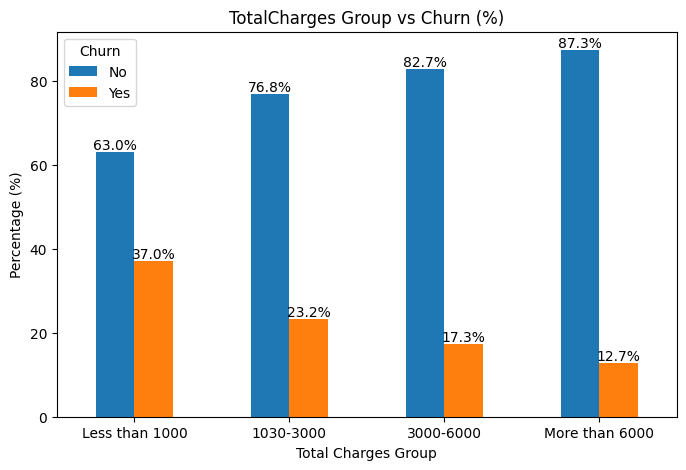

In [100]:
# Show Churn Rate per TotalCharges
# Counts Table
totalcharges_churn = pd.crosstab(df["TotalCharges_Group"], df["Churn"])

print("TotalCharges Group vs Churn (Counts):")
display(totalcharges_churn)

# Percentages Table
totalcharges_churn_pct = pd.crosstab(
    df["TotalCharges_Group"],
    df["Churn"],
    normalize="index"
) * 100
print("TotalCharges Group vs Churn (Percentage):")
display(totalcharges_churn_pct.round(2))

# Plot Counts
totalcharges_churn.plot(kind="bar", figsize=(8, 5))
plt.title("TotalCharges Group vs Churn (Count)")
plt.xlabel("Total Charges Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Plot Percentages
totalcharges_churn_pct.plot(kind="bar", figsize=(8, 5))
plt.title("TotalCharges Group vs Churn (%)")
plt.xlabel("Total Charges Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

# Add percentage Labels on Bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.1f%%")

plt.show()

## Feature Engineering

In [101]:
# Convert Target Variable into Binary Values (Yes = 1, No = 0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
print("Mapped Churn column:")
display(df["Churn"].head())

Mapped Churn column:


0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [102]:
# Drop Unnecessary Columns
# customerID is only an identifier and not useful for prediction
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

In [103]:
# Apply one-hot encoding to categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

print("Encoded dataset shape:", df_encoded.shape)
display(df_encoded.head())

Encoded dataset shape: (7032, 34)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalCharges_Group_1030-3000,TotalCharges_Group_3000-6000,TotalCharges_Group_More than 6000
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,True,False,False,False,False,True,True,False,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False


In [104]:
# Correlation Analysis - Show top correlations with the target variable
corr_with_target = df_encoded.corr()["Churn"].sort_values(ascending=False)

print("Top Positive Correlations with Churn:")
display(corr_with_target.head(10))

print("Top Negative Correlations with Churn:")
display(corr_with_target.tail(10))

Top Positive Correlations with Churn:


Churn                             1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
PhoneService_Yes                  0.011691
Name: Churn, dtype: float64

Top Negative Correlations with Churn:


TotalCharges                           -0.199484
InternetService_No                     -0.227578
DeviceProtection_No internet service   -0.227578
OnlineBackup_No internet service       -0.227578
OnlineSecurity_No internet service     -0.227578
StreamingMovies_No internet service    -0.227578
StreamingTV_No internet service        -0.227578
TechSupport_No internet service        -0.227578
Contract_Two year                      -0.301552
tenure                                 -0.354049
Name: Churn, dtype: float64

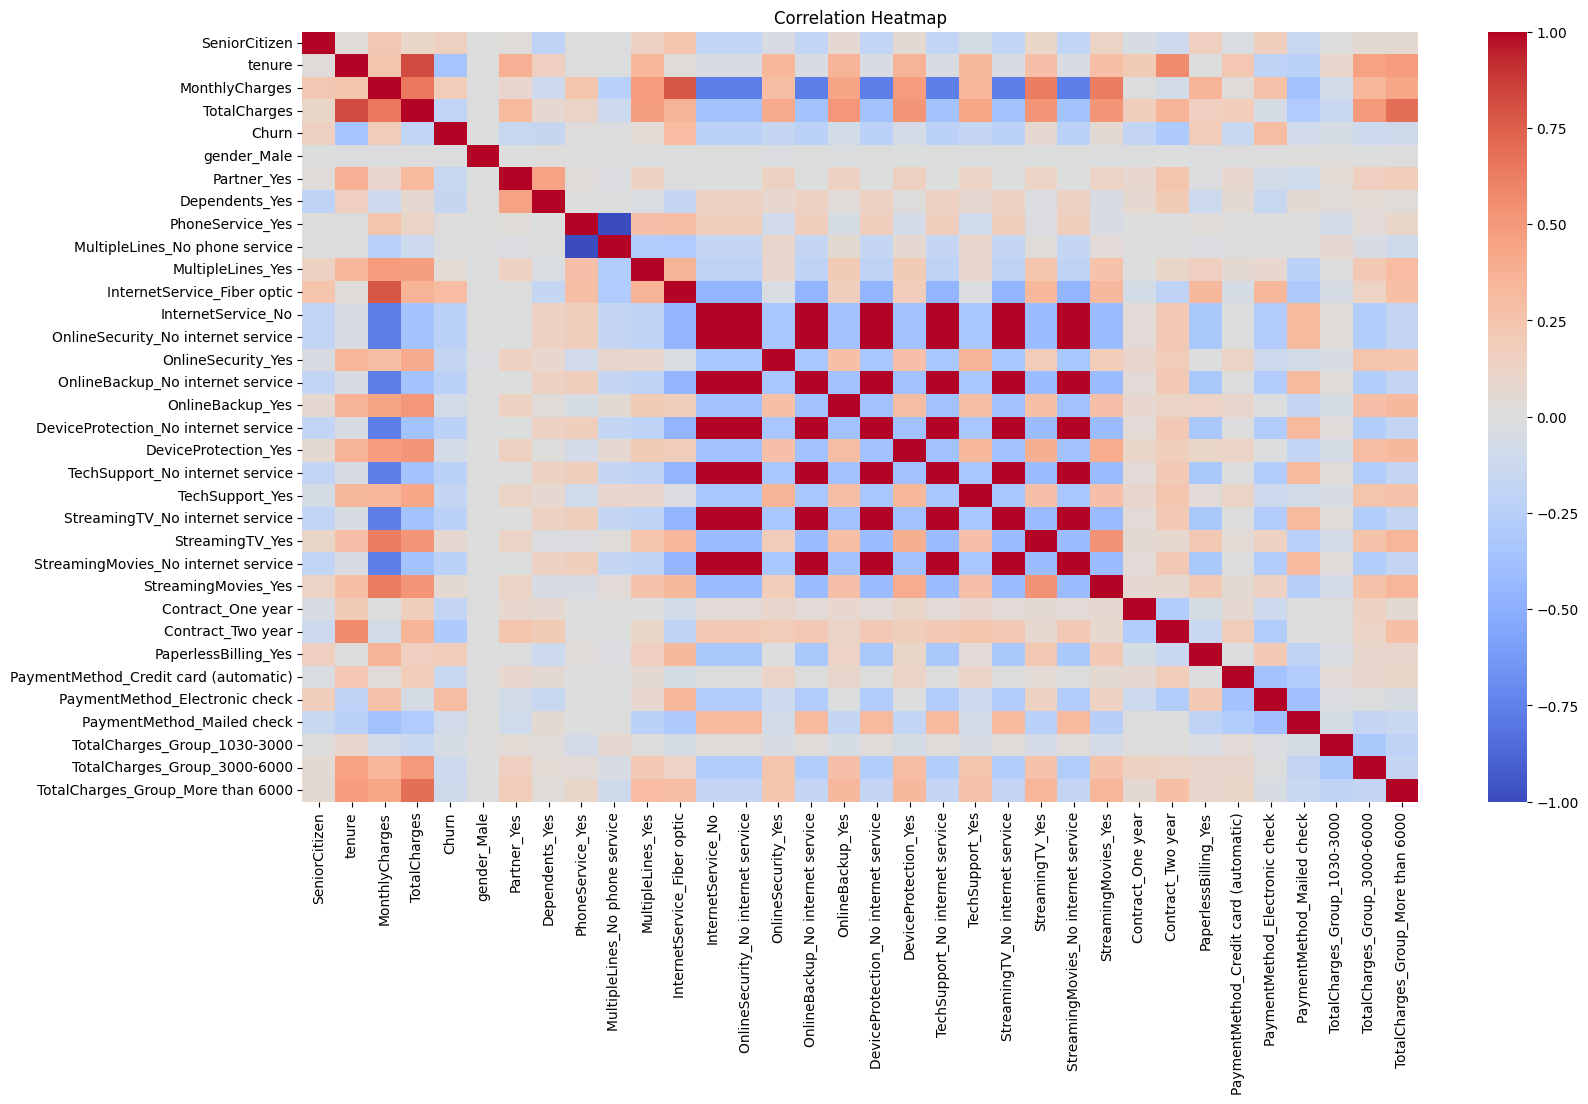

In [105]:
#Plot a correlation heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Model Building

In [106]:
# Define Features and Target
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (7032, 33)
Target vector shape: (7032,)


In [107]:
# Split Dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [108]:
# Build the XGBoost classifier
model = xgb.XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

In [109]:
# Train the model
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [110]:
# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## Results

In [111]:
# Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy Score:", accuracy)
print("ROC-AUC Score:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.7953091684434968
ROC-AUC Score: 0.837923394298316

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1033
           1       0.63      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



Confusion Matrix:
[[914 119]
 [169 205]]


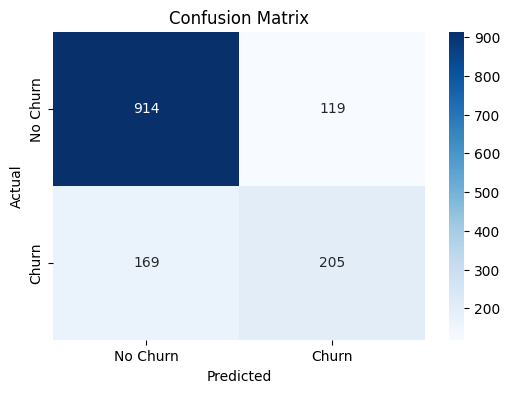

In [112]:
# Display the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

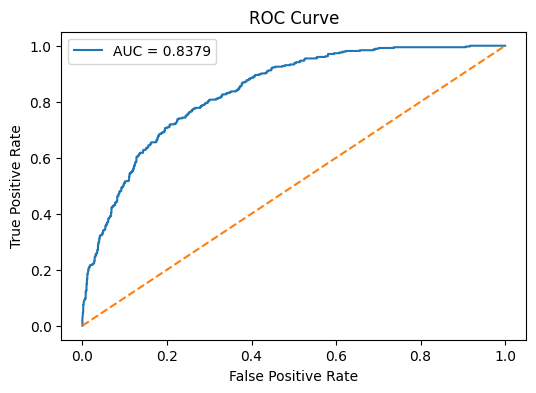

In [113]:
# Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

<Figure size 1000x800 with 0 Axes>

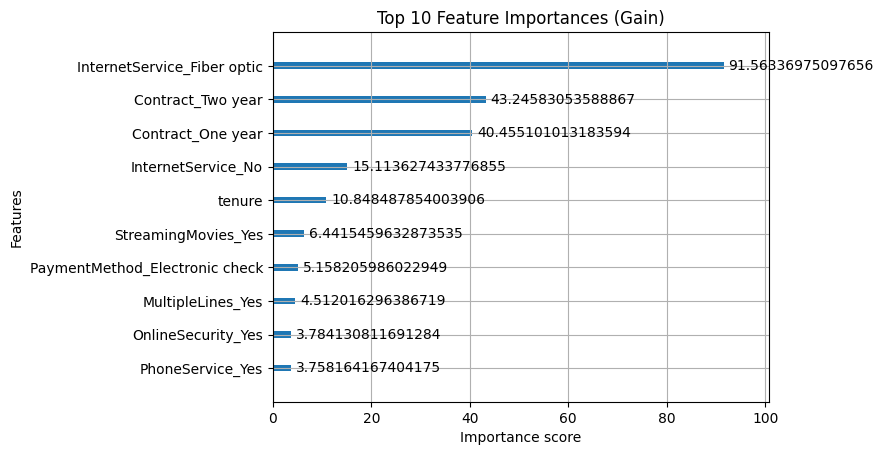

In [114]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, importance_type="gain", max_num_features=10)
plt.title("Top 10 Feature Importances (Gain)")
plt.show()

In [115]:
# Show the top 10 most important features in table form

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top 10 Most Important Features:")
display(feature_importance.head(10))

Top 10 Most Important Features:


,Feature,Importance
10,InternetService_Fiber optic,0.348497
25,Contract_Two year,0.164597
24,Contract_One year,0.153975
11,InternetService_No,0.057524
1,tenure,0.041290
23,StreamingMovies_Yes,0.024517
28,PaymentMethod_Electronic check,0.019632
9,MultipleLines_Yes,0.017173
13,OnlineSecurity_Yes,0.014403
7,PhoneService_Yes,0.014304


In [116]:
# 29. Final summary output

print("========== FINAL SUMMARY ==========")
print(f"Dataset shape after cleaning: {df.shape}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nTop 5 Most Important Features:")
print(feature_importance.head(5).to_string(index=False))

========== FINAL SUMMARY ==========
Dataset shape after cleaning: (7032, 21)
Training samples: 5625
Testing samples: 1407
Accuracy: 0.7953
ROC-AUC: 0.8379

Top 5 Most Important Features:
                    Feature  Importance
InternetService_Fiber optic    0.348497
          Contract_Two year    0.164597
          Contract_One year    0.153975
         InternetService_No    0.057524
                     tenure    0.041290
